## Examen Practico - Tercer Parcial

#### 0) Cargar una de las imágenes histológicas

####  Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
#### Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
#### Visualizar la imagen

* import numpy as np =Librería utilizada para realizar cálculos matemáticos de alto rendimiento se asigna al alias np para simplificar su uso en el código
* from skimage import io =Módulo de la librería scikit image destinado al procesamiento de imágenes Su función principal es transformar archivos de imagen (como PNG o JPG) en matrices numéricas.

In [2]:
import numpy as np  # sirve para realizar calculos matemáticos de alto rendimiento y se asigna a np para que no se escriba completo 
from skimage import io # es una libreria estandar en python sirve para prosesar imágenes su funcion principal es transformar las imágenes en matrices numericas como png jpg
import matplotlib.pyplot as plt # es el encargado de generar graficos estadisticos y matematicos en python transforma numero o matrices o listas en representaciones visuales 
import cv2# sirve para cargar en python la libreria open cv es una herammienta muy importante en visualizacion artificial en procesamiento de imágenes o videos en forma real 
from skimage.measure import label, regionprops # sirve para detectar contar o medir objetos dentro de una imagen binaria a una imagen en blanco negro donde los objetos son blancos y el fondo es negro 
from scipy.ndimage import binary_fill_holes#sirve para rellenar automáticamente los huecos o agujeros negros que quedan dentro de los objetos blancos en una imagen binaria 


In [3]:
#lo que estamos haciendo es  buscar el archivo de la imagen llamado histo y lo guardamos en un a una nueva variable llamada imagen 
# con la funcion shape lo qu eetsamos haciendo es devolver una tupla con numeros de datos 
#el primer número que parese es la altura de la imagen en pixeles filas
# el segundo número es el ancho de pixeles de la imagen columnas
# el numero tres quiere decir que la imagen esta en color en un formato de rgb  # color rojo verde y azul rgb
imagen = io.imread('histo_1.jpg')
print(imagen.shape)


(1024, 1024, 3)


In [4]:
# lo que hice es tomar cada uno de los pixeles de la imagen y dividir entre 255.0
rgb = imagen / 255.0

imagen_normalizada = imagen / 255.0

print("Valor mínimo:", np.min(imagen_normalizada)) # Salida: 0.0#busca el pixel mas obscuro de toda la imagen al dar 0 esto dice que las zonas totalmente negras ahora valen céro 
print("Valor máximo:", np.max(imagen_normalizada)) # Salida: 1.0#busca el pixel mas brillante de toda la imagen esto nos dice que las zonas en blanco puro ahora valen uno 


Valor mínimo: 0.0
Valor máximo: 1.0


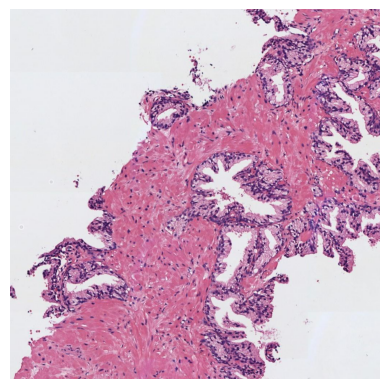

In [5]:
plt.imshow(imagen)
plt.axis('off')
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

In [6]:
# Extraer la componente magenta de la imagen que corresponde a la región tisular
# Visualizar la imagen del canal magenta

In [7]:
with np.errstate(invalid='ignore', divide='ignore'):# este codigo le dice a python que si encuntra divisiones por céro o valores invalidos los ignore y continue 
    K = 1 - np.max(rgb, axis=2) #busca el valor máximo en los canales de rojo verde y azul y que se mueva atraves de la profundidad del color en el modelo cmy k representa la usencia de l aluz rflejada 
    C = (1 - rgb[:, :, 0] - K) / (1 - K) #cian,rojo
    M = (1 - rgb[:, :, 1] - K) / (1 - K) #magenta,verde
    Y = (1 - rgb[:, :, 2] - K) / (1 - K) # amarillo 
    #todos estos colores se restan en 1 y obtienen el color opuesto es decir extrae toda la capa del rojo y obtiene el color opuesto al cian
#Finalmente se dividen entre (1 - K) para estandarizar el contraste y remover la influencia del color negro en la mezcla.k=color negro

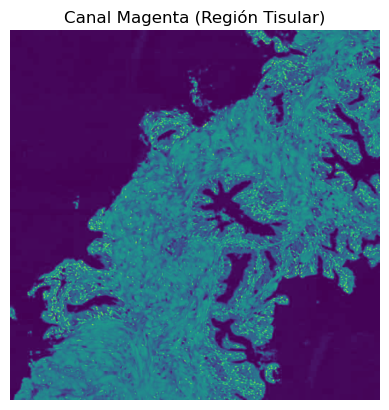

In [8]:
#extraemos la magenta extraida 
plt.imshow(M)
plt.title("Canal Magenta (Región Tisular)")
plt.axis('off')
plt.show()


#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

In [9]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

In [10]:
#  Convertimos a rango 0-255 en formato uint8 que se tranforma a números flotantes de son 8 bits usando la variable Magenta de arriba
M_uint8 = (M * 255).astype(np.uint8)
# astype su función es transformar el canal Magenta en números decimáles matemáticos a un formato de imagen estandar para que la computadora pueda guardarlo o procesarlo como un archivo visual

In [11]:
blur = cv2.GaussianBlur(M_uint8, (5, 5), 0)
# estamos reducciondo los cambios bruscos de la imagen para que se vea mas limpia 

In [12]:
# 3. Aplicamos el método de otsu invertido sobre la imagen filtrada blur
t, mask = cv2.threshold(blur, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print("Valores únicos en la máscara:", np.unique(mask))
#estamos semegtando la imagen filtrada para separar objeto y fondo usando un umbral calculado por outsu invertimos el resultado para que el fondo sea blanco y el objeto negro 


Valores únicos en la máscara: [0 1]


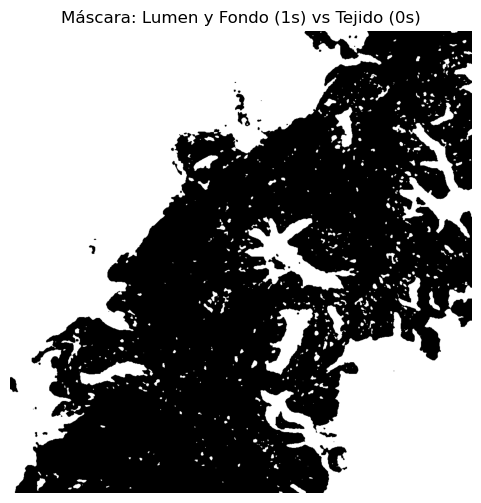

In [13]:
# 4. Visualizar la máscara resultante usando la variable 'mask'
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap='gray')
plt.title("Máscara: Lumen y Fondo (1s) vs Tejido (0s)")
plt.axis('off')
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

In [14]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

In [15]:
from skimage.morphology import remove_small_objects
mask_bool = mask.astype(bool)
#convertimos la mascara a tipo booleano verdadero falso es un requisito obligatorio de skimage 

In [16]:
mask_limpia = remove_small_objects(mask_bool, min_size=300)
#eliminamos los objetos blancos  cuyo tamaño sea menor a 300 pixeles

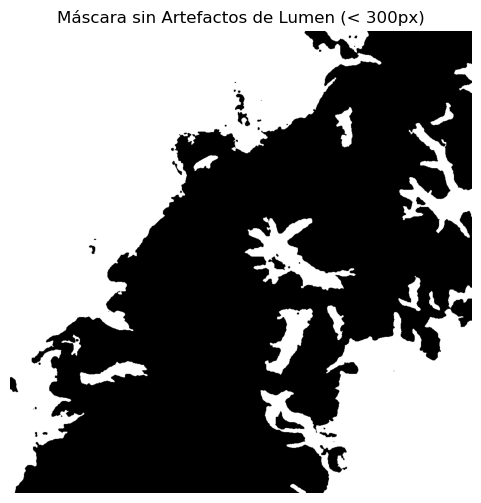

In [17]:
#visualizamos la mascara limpia 
plt.figure(figsize=(6, 6))
plt.imshow(mask_limpia, cmap='gray')
plt.title("Máscara sin Artefactos de Lumen (< 300px)")
plt.axis('off')
plt.show()


#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [18]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

In [19]:
if len(imagen.shape) == 3:
    img_gris = (np.mean(imagen, axis=2) * 255).astype(np.uint8) if imagen.dtype == float else np.mean(imagen, axis=2).astype(np.uint8)
else:
    img_gris = (imagen * 255).astype(np.uint8) if imagen.dtype == float else imagen.copy()
# preparamos la imagen a grises 

In [20]:

def encontrar_semillas_automaticas(mascara_limpia, num_semillas=2):
    #etiquetamos los componentes de la mascara limpia 
    etiquetas = label(mascara_limpia)
    propiedades = regionprops(etiquetas)
    
    # Centro de la imagen para calcular distancias
    alto, ancho = mascara_limpia.shape
    centro_img = np.array([alto / 2, ancho / 2])
    
    candidatos = []
    for prop in propiedades:
        # Calcular la distancia del centroide de cada objeto al centro del lienzo
        centroide = np.array(prop.centroid) # (fila, columna) -> (y, x)
        distancia = np.linalg.norm(centroide - centro_img)
        candidatos.append((distancia, centroide))
    
    # Ordenar por cercania al centro de la imagen
    candidatos.sort(key=lambda x: x[0])
    
    # Guardar las coordenadas en formato x, y para el algoritmo
    semillas = [(int(c[1][1]), int(c[1][0])) for c in candidatos[:num_semillas]]
    return semillas

In [21]:

def region_growing(imagen_base, semillas, umbral=15):
    alto, ancho = imagen_base.shape
    mascara_resultado = np.zeros_like(imagen_base, dtype=np.uint8)
    lista_pixeles = []
    
    # Inicializar con las semillas encontradas
    for (x, y) in semillas:
        lista_pixeles.append((y, x))
        mascara_resultado[y, x] = 255
        
    vecinos = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    while len(lista_pixeles) > 0:
        y_act, x_act = lista_pixeles.pop(0)
        valor_actual = imagen_base[y_act, x_act]
        
        for dy, dx in vecinos:
            y_v, x_v = y_act + dy, x_act + dx
            if 0 <= y_v < alto and 0 <= x_v < ancho:
                if mascara_resultado[y_v, x_v] == 0:
                    # Criterio de homogeneidad basado en el umbral de tonos de gris
                    if abs(int(imagen_base[y_v, x_v]) - int(valor_actual)) < umbral:
                        mascara_resultado[y_v, x_v] = 255
                        lista_pixeles.append((y_v, x_v))
                        
    return mascara_resultado

Semillas de lúmenes localizadas automáticamente en (X, Y): [(622, 500), (620, 678)]


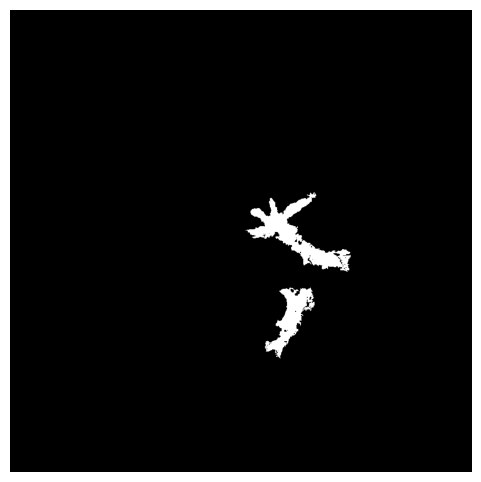

In [22]:

#  Detectar las 2 semillas de forma automa'aática 
semillas = encontrar_semillas_automaticas(mask_limpia, num_semillas=2)
print(f"Semillas de lúmenes localizadas automáticamente en (X, Y): {semillas}")

# Ejecutamos el crecimiento de regiones Creamos la máscara blanca negra
mascara_final = region_growing(img_gris, semillas, umbral=12)

# Mostrar el resultado
plt.figure(figsize=(6, 6))
plt.imshow(mascara_final, cmap='gray')
plt.axis('off') # Quita bordes y coordenadas numéricas por completo
plt.show()

#### 5) Rellenar los objetos de los lúmenes

In [23]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

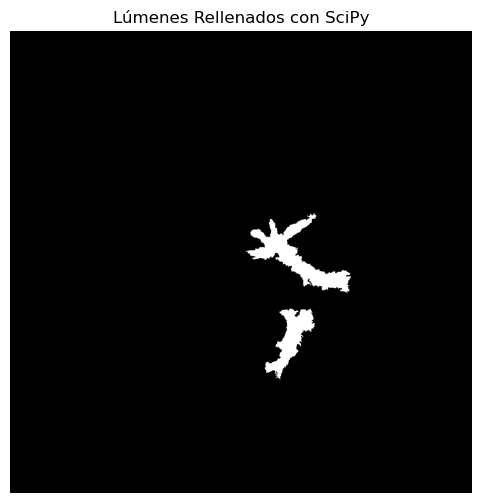

In [24]:
# aplicamos la funcion binary_fill  de la libreria scipy 
lumenes_rellenos = binary_fill_holes(mascara_final)

#visualizacion limpia 
plt.figure(figsize=(6, 6))

# Mostramos el resultado convirtiendo el booleano a entero
plt.imshow(lumenes_rellenos.astype(np.uint8) * 255, cmap='gray')

plt.title("Lúmenes Rellenados con SciPy")
plt.axis('off') # Mantenemos la pantalla limpia sin números en las coordenadas

plt.show()

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

In [25]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta


In [26]:
# 1. Crear una copia de la imagen original para no arruinar la variable original
img_out = imagen.copy()

In [27]:
# 2. Asegurar que la mascara este limpia y en formato uint8 0 o 255
mask_uint8 = mask_limpia.astype(np.uint8) * 255
mask_uint8[0:5, :] = 0
mask_uint8[-5:, :] = 0
mask_uint8[:, 0:5] = 0
mask_uint8[:, -5:] = 0

In [28]:
# 3. Detectamos todos los contornos externos de los lumenes
contornos, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [29]:
# 4. Dibujar los contornos en verde puro R=0, G=255, B=0 con grosor de 4 pixeles para que se vea mejor 
# Como la imagen esta en formato rgb el color se pasa como 0, 255, 0
cv2.drawContours(img_out, contornos, -1, (0, 255, 0), 4)

array([[[233, 237, 240],
        [233, 237, 240],
        [233, 237, 240],
        ...,
        [172, 122, 173],
        [189, 141, 193],
        [184, 137, 191]],

       [[233, 237, 240],
        [233, 237, 240],
        [233, 237, 240],
        ...,
        [189, 136, 188],
        [211, 163, 215],
        [213, 166, 218]],

       [[233, 237, 240],
        [233, 237, 240],
        [233, 237, 240],
        ...,
        [181, 129, 178],
        [212, 162, 213],
        [229, 181, 231]],

       ...,

       [[231, 232, 237],
        [231, 232, 236],
        [232, 231, 236],
        ...,
        [232, 233, 237],
        [232, 233, 237],
        [232, 233, 237]],

       [[231, 232, 237],
        [231, 232, 236],
        [232, 231, 236],
        ...,
        [232, 233, 237],
        [232, 233, 237],
        [232, 233, 237]],

       [[231, 232, 237],
        [231, 232, 236],
        [232, 231, 236],
        ...,
        [232, 233, 237],
        [232, 233, 237],
        [232, 233, 237]]

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

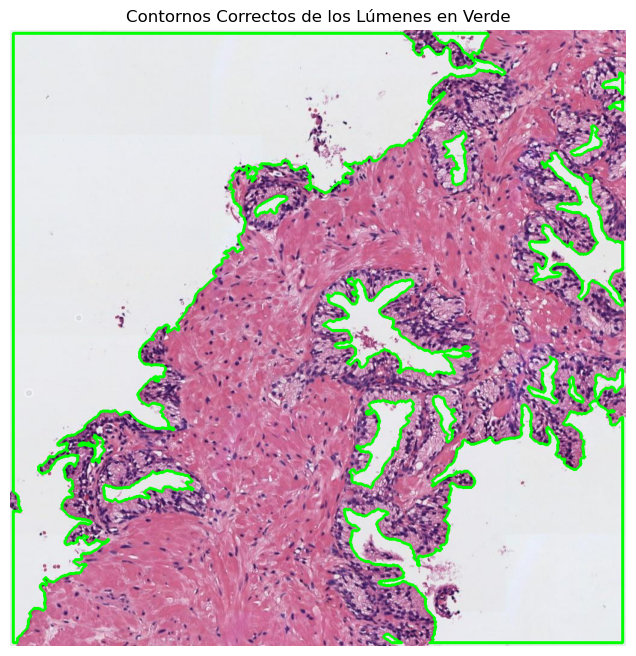

In [30]:
# 5. Visualizamos la imagen con la superposición corregida
plt.figure(figsize=(8, 8))
plt.imshow(img_out)
plt.title("Contornos Correctos de los Lúmenes en Verde")
plt.axis('off')

#### 7) Identificar y cropear el lumen más grande

In [31]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

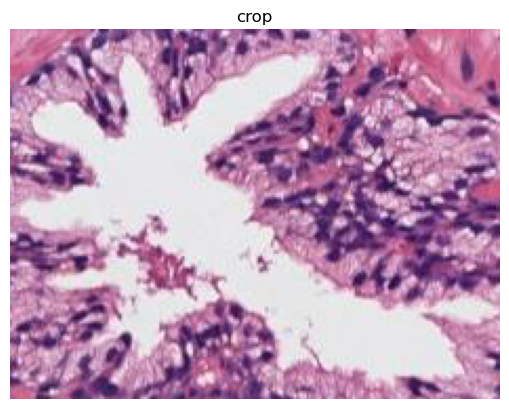

In [32]:
# esta es nuestra imagen original en rgb 
imagen = io.imread('histo_1.jpg')

lumenes_etiquetados = label(lumenes_rellenos)# esta funcion lo que hace es asignar un unico numero a una region conectada para poder indentificarlso 
propiedades = regionprops(lumenes_etiquetados)# ordena la region por area 
propiedades_ordenadas = sorted(propiedades, key=lambda x: x.area, reverse=True)# selecionar la region mas grande 
lumen_mayor = propiedades_ordenadas[0]# en esta funcion toma la region mas grande 

min_y, min_x, max_y, max_x = lumen_mayor.bbox# en este codigo recolectamos la imagen original 
new_img = imagen[min_y:max_y, min_x:max_x]# en este codigo mostramos la imagen recortada 

figs, ax = plt.subplots()
ax.imshow(new_img)
ax.set_title('crop')
ax.axis('off') 
plt.show()
 #localiza el lumen mas grande y lo recorta

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [33]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

In [34]:
# 1) Área
print(f"1) Área: {lumen_mayor.area:.4f}")


1) Área: 11484.0000


In [35]:
# 2) Área de la bounding box
print(f"2) Área de la bounding box: {lumen_mayor.area_bbox:.4f}")


2) Área de la bounding box: 41008.0000


In [36]:
# 3) Área convexa
print(f"3) Área convexa: {lumen_mayor.area_convex:.4f}")


3) Área convexa: 26322.0000


In [37]:
# 4) Excentricidad
print(f"4) Excentricidad: {lumen_mayor.eccentricity:.4f}")


4) Excentricidad: 0.9067


In [38]:
# 5) Diámetro equivalente
print(f"5) Diámetro equivalente: {lumen_mayor.equivalent_diameter:.4f}")
#equivalent_diameter_area  la proxima version de la libreria 

5) Diámetro equivalente: 120.9210


In [39]:
# 6) Extensión
print(f"6) Extensión: {lumen_mayor.extent:.4f}")


6) Extensión: 0.2800


In [40]:
# 7) Diámetro Feret
import numpy as np
try:
    diametro_feret = lumen_mayor.feret_diameter_max
except AttributeError:
    min_y, min_x, max_y, max_x = lumen_mayor.bbox
    diametro_feret = np.sqrt((max_y - min_y)**2 + (max_x - min_x)**2)

print(f"7) Diámetro Feret: {diametro_feret:.4f}")


7) Diámetro Feret: 255.3684


In [41]:
# 8) Longitud del eje mayor
print(f"8) Longitud del eje mayor: {lumen_mayor.axis_major_length:.4f}")


8) Longitud del eje mayor: 266.1599


In [42]:
# 9) Longitud del eje menor
print(f"9) Longitud del eje menor: {lumen_mayor.axis_minor_length:.4f}")


9) Longitud del eje menor: 112.2712


In [43]:
# 10) Orientación
print(f"10) Orientación: {lumen_mayor.orientation:.4f}")


10) Orientación: 0.9745


In [44]:
# 11) Perímetro
print(f"11) Perímetro: {lumen_mayor.perimeter:.4f}")


11) Perímetro: 1245.6671


In [45]:
# 12) Solidez
print(f"12) Solidez: {lumen_mayor.solidity:.4f}")


12) Solidez: 0.4363


In [46]:
# 13) Compacidad
import numpy as np
compacidad = (lumen_mayor.perimeter ** 2) / (4 * np.pi * lumen_mayor.area)
print(f"13) Compacidad: {compacidad:.4f}")


13) Compacidad: 10.7523
